# Plotting a Visium dataset

This tutorial shows how to use `spatialdata-plot` on a real 10x Genomics Visium experiment: render the H&E tissue image, render the spots, overlay them, color spots by gene expression and by cluster, then build a publication-style figure.

**Dataset**: a Visium H&E mouse brain section, downloaded by `squidpy.datasets.visium_hne_sdata` from the scverse example data host. The download (~400 MB) is cached after the first run.

**Credit**: the example progression here (H&E + spots, gene-expression overlay, outline styling) was originally curated by [@asarigun] in [scverse/spatialdata-plot#590].

[@asarigun]: https://github.com/asarigun
[scverse/spatialdata-plot#590]: https://github.com/scverse/spatialdata-plot/pull/590

## Loading the dataset

`squidpy.datasets.visium_hne_sdata()` returns a ready-to-plot `SpatialData` object containing the multi-resolution H&E image, the spot polygons, and the linked `AnnData` table.

In [1]:
import squidpy as sq

import spatialdata_plot  # noqa: F401  (registers the .pl accessor)

sdata = sq.datasets.visium_hne_sdata()
sdata

INFO     Downloading visium_hne_sdata.zip from                                                                     
         https://exampledata.scverse.org/squidpy/figshare/visium_hne_sdata.zip                                     


INFO     Extracting                                                                                                
         data/spatialdata/visium_hne_sdata.z
         ip to data/spatialdata                                                                                    


SpatialData object, with associated Zarr store: data/spatialdata/visium_hne_sdata.zarr
├── Images
│     └── 'hne': DataTree[cyx] (3, 11757, 11291), (3, 5878, 5645), (3, 2939, 2822), (3, 1469, 1411)
├── Shapes
│     └── 'spots': GeoDataFrame shape: (2688, 2) (2D shapes)
└── Tables
      └── 'adata': AnnData (2688, 18078)
with coordinate systems:
    ▸ 'global', with elements:
        hne (Images), spots (Shapes)

## Rendering the tissue image

The H&E image is a standard three-channel RGB image stored at multiple resolutions; `render_images` picks an appropriate scale automatically.

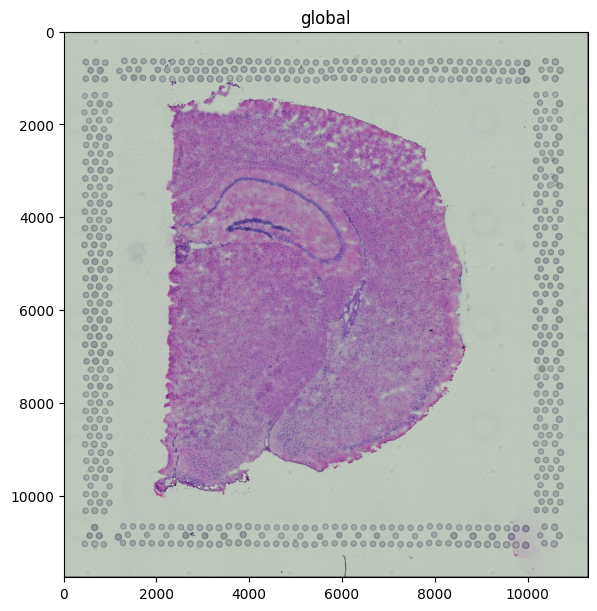

In [2]:
sdata.pl.render_images("hne").pl.show(figsize=(6, 6))

## Rendering spots on their own

Visium spots are stored as `shapes`. Rendered alone they show the regular hexagonal capture pattern.

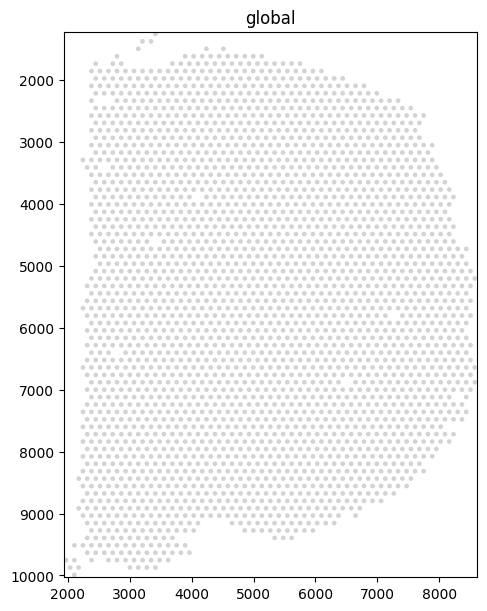

In [3]:
sdata.pl.render_shapes("spots").pl.show(figsize=(6, 6))

## Overlay: tissue + spots

The fluent API chains the two renders. Use `fill_alpha` on the spots so the underlying tissue stays visible.

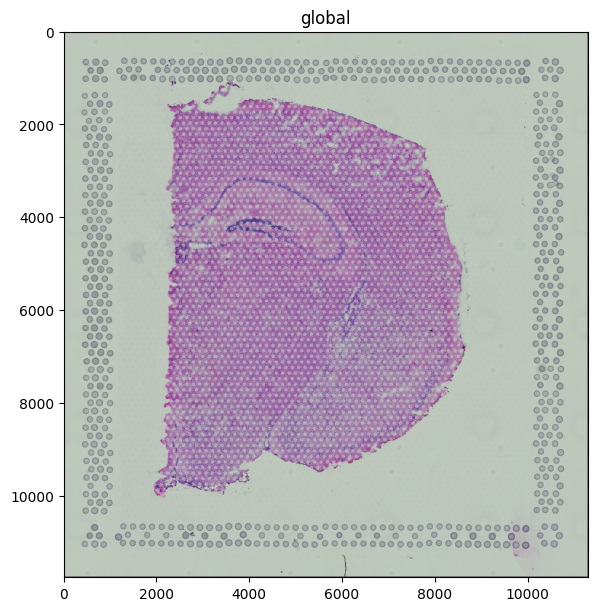

In [4]:
(
    sdata.pl.render_images("hne")
    .pl.render_shapes("spots", fill_alpha=0.5)
    .pl.show(figsize=(6, 6))
)

## Coloring spots by gene expression

Pass `color=<gene>` to map a column from the linked table onto the spot fill. `Mbp` (Myelin Basic Protein) is a classic white-matter marker; the expression pattern traces the corpus callosum and other myelinated tracts of the brain section.

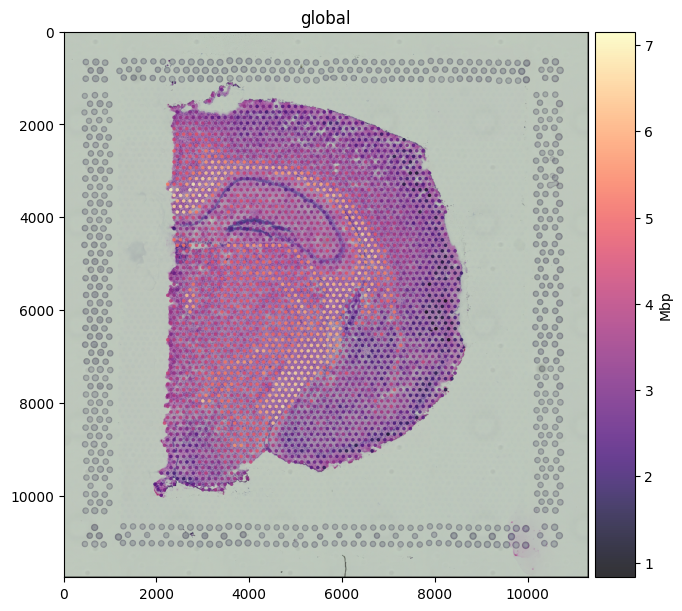

In [5]:
(
    sdata.pl.render_images("hne")
    .pl.render_shapes("spots", color="Mbp", cmap="magma", fill_alpha=0.8)
    .pl.show(figsize=(6, 6))
)

## Coloring spots by a categorical annotation

`color=` also accepts categorical columns from `obs`. The dataset ships with `cluster` labels from a Leiden clustering run.

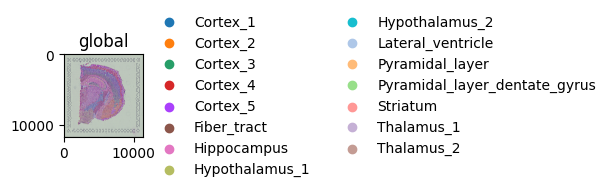

In [6]:
(
    sdata.pl.render_images("hne")
    .pl.render_shapes("spots", color="cluster", fill_alpha=0.7)
    .pl.show(figsize=(6, 6))
)

## Publication-style styling

For a polished figure: keep the tissue context, color the spots by expression with a perceptually uniform colormap, draw a thin white outline so the spots stand out against the H&E, and use a translucent fill so the histology underneath stays readable.

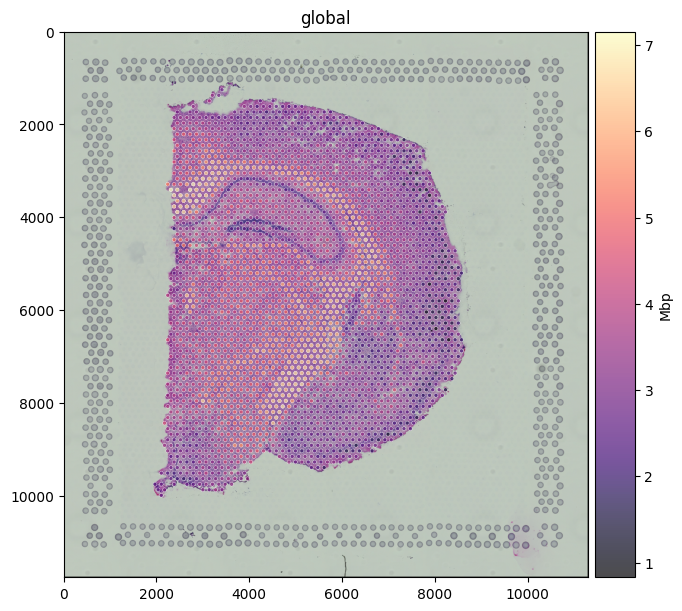

In [7]:
(
    sdata.pl.render_images("hne")
    .pl.render_shapes(
        "spots",
        color="Mbp",
        cmap="magma",
        fill_alpha=0.7,
        outline_width=0.4,
        outline_color="white",
        outline_alpha=1.0,
    )
    .pl.show(figsize=(6, 6))
)

## For reproducibility

In [8]:
# ruff: noqa: F401, F811, I001
# fmt: off
import warnings
import dask
import spatialdata_plot

%load_ext watermark
# fmt: on

%watermark -v -m -p timeit,warnings,dask,datashader,matplotlib,numpy,pandas,scanpy,spatialdata,spatialdata_plot,geopandas,shapely

Python implementation: CPython
Python version       : 3.13.7
IPython version      : 9.13.0

timeit          : unknown
warnings        : unknown
dask            : 2026.1.1
datashader      : 0.19.0
matplotlib      : 3.10.9
numpy           : 2.4.4
pandas          : 2.3.3
scanpy          : 1.12.1
spatialdata     : 0.7.3
spatialdata_plot: 0.3.3
geopandas       : 1.1.3
shapely         : 2.1.2

Compiler    : Clang 15.0.0 (clang-1500.1.0.2.5)
OS          : Darwin
Release     : 25.2.0
Machine     : arm64
Processor   : arm
CPU cores   : 8
Architecture: 64bit

